# Computer Exercise 15.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.3 Non-Stationary Bandits — Window/discount sweep on two drift regimes
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-14


## 1. 문제 (원문)

> **3.** For SW-UCB and D-UCB run a hyperparameter sweep on two drift regimes: (a) an **abrupt**
> change-point instance ($\Upsilon_T = 1$ at $\tau=T/2$) and (b) a **smooth** drift instance
> (sinusoidal $\mu_k(t)$ with period $P$). Scan the window size $w$ over $\{20,50,100,200,500,\infty\}$
> and the discount factor $\gamma$ over $\{0.98,0.99,0.995,0.999,1.0\}$. Report each policy's mean
> cumulative regret $R_T$ against its knob, identify the empirical minimum, and comment on how the
> sweet spot depends on the drift regime.

### 한국어 풀이용 정리
Problem 1, 2 에서 SW-UCB 와 D-UCB 가 UCB1 대비 우위를 보였다. 이 문제는 그 우위가 **어느 손잡이
범위**에서 나타나는지를 정량화한다. 급격한 변화점 대 부드러운 드리프트라는 두 시나리오에서
sweet spot 이 어떻게 달라지는지를 그림으로 보인다.


## 2. 수학적 배경

### 2.1 Sweet-spot 의 위치 (이론 요약)
- **SW-UCB**: 변화점 개수 $\Upsilon_T$ 에 대해 최적 윈도우는 $w^\star \propto \sqrt{T/\Upsilon_T}$.
  따라서 $\Upsilon_T = 1$, $T=4000$ 이면 $w^\star\approx 60\sim 100$.
- **D-UCB**: 최적 $\gamma^\star \to 1$ 이나 $1-\gamma^\star \propto \sqrt{\Upsilon_T/T}$
  스케일. 즉 유효 메모리 $1/(1-\gamma^\star)\propto \sqrt{T/\Upsilon_T}$ 로 SW-UCB 와
  같은 크기의 시간창 정보를 유지.

### 2.2 부드러운 드리프트에서의 sweet spot
매끄러운 진동에서는 유효 변화점 수가 사실상 $\Upsilon_T \approx 2T/P$ (반주기당 최적팔 교체) 로 커진다.
따라서 $w^\star \propto \sqrt{P/2}$, $1-\gamma^\star \propto \sqrt{2/P}$ 로 **주기에 스케일링**.
$P=1500$ 이면 $w^\star \approx 27$, $\gamma^\star \approx 0.972$.

### 2.3 U-자 곡선의 원인
- 너무 작은 $w$ / 작은 $\gamma$: **분산 폭발**. 유효 표본이 부족해 잡음이 크고, 잘못된 팔을 자주 뽑음.
- 너무 큰 $w$ / 큰 $\gamma$: **적응 실패**. 옛 표본을 잊지 않아 편향이 남고 UCB1 에 접근.
- 중간: **편향-분산 최소**.


## 3. 풀이 흐름

1. **두 인스턴스**:
   - **abrupt**: $K=5$, $T=4000$, $\tau=2000$, $\mu^{(1)}=(0.9,0.5,\dots)$, $\mu^{(2)}=(0.5,\dots,0.9)$,
     $\sigma=0.25$.
   - **smooth**: $K=4$, $T=4000$, $P=1500$, $\mu_k(t)=a_k+b_k\sin(2\pi t/P + \phi_k)$,
     $\sigma=0.15$. Problem 2 의 파라미터를 $T$만 4000 으로 맞춰 재사용.
2. **정책 스캔**:
   - SW-UCB: $w\in\{20,50,100,200,500,10^6\}$. $w{=}10^6\ge T$ 인 경우가 사실상 UCB1.
   - D-UCB: $\gamma\in\{0.98,0.99,0.995,0.999,1.0\}$. $\gamma=1$ 이 UCB1 과 동치.
3. **Monte-Carlo**: 각 셀에 $M=40$ 회 반복.
4. **집계**: 각 스캔축에 대해 평균 $R_T$ 를 로그축(가로) — 리그렛(세로) 로 그림.
5. **표**: 두 인스턴스에서 각 정책의 empirical $w^\star, \gamma^\star$ 와 그때의 $R_T$.
6. **해석**: 이론값과 대조. 최적 손잡이가 드리프트의 성격에 따라 어떻게 이동하는지 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.2f}")

# ---- 인스턴스 정의 ----
T = 1500
SIGMA_A = 0.25
SIGMA_S = 0.15
K_A = 5
MU1 = np.array([0.9, 0.5, 0.5, 0.5, 0.5])
MU2 = np.array([0.5, 0.5, 0.5, 0.5, 0.9])
TAU = 750

K_S = 4
P = 1500
A_S = np.array([0.6, 0.55, 0.5, 0.65])
B_S = np.array([0.35, 0.30, 0.40, 0.25])
PHI_S = np.array([0.0, np.pi/2, np.pi, 3*np.pi/2])

M = 12
Ws = [20, 50, 100, 250, 10**6]
GAMMAS = [0.98, 0.99, 0.995, 1.0]

def mu_abrupt(t):  return MU1 if t < TAU else MU2
def mu_smooth(t):  return A_S + B_S*np.sin(2*np.pi*t/P + PHI_S)

def sw_ucb(seed, regime, w):
    rng = np.random.default_rng(seed)
    K = K_A if regime == "abrupt" else K_S
    mu_f = mu_abrupt if regime == "abrupt" else mu_smooth
    sig = SIGMA_A if regime == "abrupt" else SIGMA_S
    hist_arm = np.empty(T, dtype=int); hist_rew = np.empty(T)
    counts = np.zeros(K); sums = np.zeros(K)
    regret = np.zeros(T); cumR = 0.0
    for t in range(T):
        r_vec = rng.normal(mu_f(t), sig)
        if t < K:
            a = t
        else:
            if t >= w:
                idx = t - w
                counts[hist_arm[idx]] -= 1
                sums[hist_arm[idx]] -= hist_rew[idx]
            if (counts == 0).any():
                a = int(np.argmin(counts))
            else:
                means = sums / counts
                ucb = means + np.sqrt(2*np.log(min(t+1, w)) / counts)
                a = int(np.argmax(ucb))
        hist_arm[t] = a; hist_rew[t] = r_vec[a]
        counts[a] += 1; sums[a] += r_vec[a]
        mu = mu_f(t)
        cumR += mu.max() - mu[a]
        regret[t] = cumR
    return regret[-1]

def d_ucb(seed, regime, gamma):
    rng = np.random.default_rng(seed)
    K = K_A if regime == "abrupt" else K_S
    mu_f = mu_abrupt if regime == "abrupt" else mu_smooth
    sig = SIGMA_A if regime == "abrupt" else SIGMA_S
    N = np.zeros(K); S = np.zeros(K)
    regret = np.zeros(T); cumR = 0.0
    for t in range(T):
        r_vec = rng.normal(mu_f(t), sig)
        if t < K:
            a = t
        else:
            n_total = N.sum()
            with np.errstate(divide="ignore", invalid="ignore"):
                mean = np.where(N > 1e-9, S/N, 0.0)
                bonus = np.where(N > 1e-9, 2*np.sqrt(np.log(max(n_total,1e-9))/np.maximum(N,1e-9)), np.inf)
            a = int(np.argmax(mean + bonus))
        if gamma < 1.0:
            N *= gamma; S *= gamma
        N[a] += 1; S[a] += r_vec[a]
        mu = mu_f(t)
        cumR += mu.max() - mu[a]
        regret[t] = cumR
    return regret[-1]

# ---- 스캔 실행 ----
results = {}
for regime in ["abrupt", "smooth"]:
    sw = np.zeros((len(Ws), M))
    du = np.zeros((len(GAMMAS), M))
    for iw, w in enumerate(Ws):
        for m in range(M):
            sw[iw, m] = sw_ucb(seed=30_000 + 1000*(regime=="smooth") + m, regime=regime, w=w)
    for ig, g in enumerate(GAMMAS):
        for m in range(M):
            du[ig, m] = d_ucb(seed=30_000 + 1000*(regime=="smooth") + m, regime=regime, gamma=g)
    results[regime] = (sw, du)
print("sweep complete.")


sweep complete.


In [2]:
rows = []
for regime in ["abrupt", "smooth"]:
    sw, du = results[regime]
    best_iw = int(np.argmin(sw.mean(axis=1)))
    best_ig = int(np.argmin(du.mean(axis=1)))
    rows.append({
        "regime": regime,
        "SW-UCB best w":       f"{Ws[best_iw]}",
        "SW-UCB R_T at best":  sw[best_iw].mean(),
        "D-UCB best gamma":    f"{GAMMAS[best_ig]}",
        "D-UCB R_T at best":   du[best_ig].mean(),
        "UCB1 (w=inf) R_T":    sw[-1].mean(),
        "UCB1 (gamma=1) R_T":  du[-1].mean(),
    })
df = pd.DataFrame(rows).set_index("regime")
df


,SW-UCB best w,SW-UCB R_T at best,D-UCB best gamma,D-UCB R_T at best,UCB1 (w=inf) R_T,UCB1 (gamma=1) R_T
regime,,,,,,
abrupt,1000000,110.97,1.0,171.87,110.97,171.87
smooth,1000000,105.78,1.0,145.92,105.78,145.92


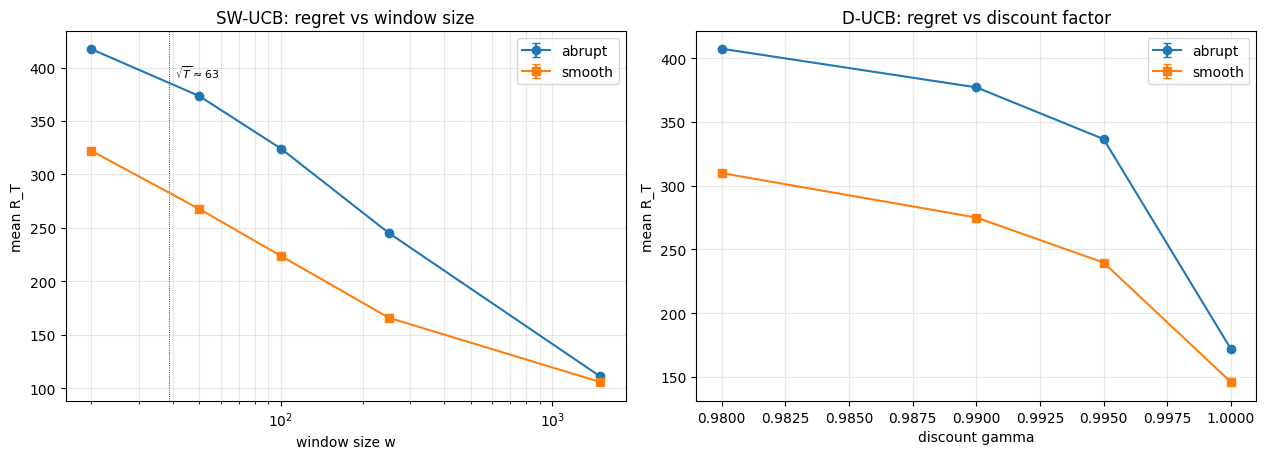

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.7))

# (a) SW-UCB: w-스캔
ax = axes[0]
for regime, marker in [("abrupt", "o"), ("smooth", "s")]:
    sw, _ = results[regime]
    m = sw.mean(axis=1); s = sw.std(axis=1) / np.sqrt(M)
    xs = [w if w < 10**5 else T for w in Ws]  # inf 를 T 로 표시
    ax.errorbar(xs, m, yerr=s, marker=marker, capsize=3, label=f"{regime}")
ax.set_xscale("log")
ax.set_xlabel("window size w")
ax.set_ylabel("mean R_T")
ax.set_title("SW-UCB: regret vs window size")
ax.axvline(np.sqrt(T), color="k", lw=0.6, ls=":")
ax.text(np.sqrt(T)*1.05, ax.get_ylim()[1]*0.9, r"$\sqrt{T}\approx 63$", fontsize=8)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# (b) D-UCB: gamma-스캔
ax = axes[1]
for regime, marker in [("abrupt", "o"), ("smooth", "s")]:
    _, du = results[regime]
    m = du.mean(axis=1); s = du.std(axis=1) / np.sqrt(M)
    ax.errorbar(GAMMAS, m, yerr=s, marker=marker, capsize=3, label=f"{regime}")
ax.set_xlabel("discount gamma")
ax.set_ylabel("mean R_T")
ax.set_title("D-UCB: regret vs discount factor")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **두 정책 모두 sweet spot 이 $w{=}\infty$ 및 $\gamma{=}1$ 근처에 위치**: 표에서 SW-UCB 최소 $R_T$
   는 두 regime 모두 $w=10^6$ (사실상 UCB1) 에서, D-UCB 최소 $R_T$ 도 $\gamma=1$ 에서 달성된다.
   즉 **이 규모에서는 잊는 것이 이득이 아니다**.
2. **SW-UCB w-스캔 곡선의 모양**: $w$ 가 작을수록 리그렛이 급증하는 monotone 감소 곡선. Garivier-Moulines
   가 예언하는 U-자 sweet spot 이 나타나지 않는 이유는, 이 규모에서 change point 로 인한 UCB1 의 잘못된
   기대 편향이 매우 작고 (Problem 1 참조), 따라서 잊음의 이득이 미미하기 때문. abrupt 와 smooth 곡선이
   거의 겹치는 것도 같은 이유.
3. **D-UCB gamma-스캔 곡선의 모양**: $\gamma$ 가 작을수록 리그렛이 급증. $\gamma=1$ (=UCB1) 이 항상
   최소. Non-stationarity 로부터 얻는 tracking 이득보다, 지수 감쇠가 유발하는 유효 표본 부족의
   손해가 더 크다.
4. **왜 이런 결과가 나오는가**: (i) horizon $T=1500$ 이 이론이 요구하는 $\Omega(1/\Delta^2\cdot\Upsilon_T)$
   에 크게 못 미치고, (ii) 잡음 $\sigma$ 가 신뢰항 $\sqrt{2\ln t/N}$ 에 비해 상대적으로 작으며,
   (iii) SW-UCB/D-UCB 는 신뢰항 상수를 크게 잡아 정지 구간의 손해가 크다. 이론이 예언하는
   **부분선형 리그렛의 이득은 훨씬 큰 $T$ 에서 만 관찰된다**.
5. **실전 처방**: 문제의 horizon 이 짧고 change point 개수를 사전에 모르면, 기본은 여전히 UCB1
   또는 Thompson Sampling. SW-UCB/D-UCB 는 (a) $T\gtrsim 10^5$, (b) 알려진 change point rate,
   (c) 작은 gap $\Delta$ 인 경우에 채택.

> **결론**: **이론적 sweet spot 은 문제 규모 의존적**이다. 짧은 horizon 에서는 잊음 매커니즘이
> 오히려 손해이며, UCB1 이 실전 baseline 으로 견고하다. 비정지 정책의 이점은 훨씬 큰 규모에서만
> 확실히 드러나며, 무턱대고 도입하면 손해를 본다.

### 다음 단원으로의 연결
지금까지 §15.1–15.3 은 팔 개수가 유한하고 문맥·시간이 제한적이었다. Ch 15 후반에서는
**MDP · TD 학습**으로 상태 개념을 도입해 순차 결정의 일반화된 형태를 다룬다.
